# Proyecto SOLARIS - Módulo 3
## Prototipo funcional del modelo de riesgo de mora

**Autor:** Nicolás Torres Castellanos  
**Curso:** Proyecto de Ciencia de Datos 2  
**Periodo académico:** 2026-2

### Objetivo
Construir y evaluar un prototipo funcional y reproducible para estimar el riesgo de mora de clientes de FrescaMar S.A.S. El notebook conserva únicamente lo necesario de los Módulos 1 y 2: preparación de datos, EDA orientado al problema, auditoría de *data leakage*, pipeline de preprocesamiento, baseline, modelo challenger, optimización, evaluación, análisis de errores y conclusiones.

### Reproducibilidad
- Notebook diseñado para ejecutarse en **Google Colab** o desde la raíz del repositorio.
- En Colab se instala de forma explícita **Optuna 5.0.0**, ya que no forma parte del entorno base garantizado.
- Las versiones realmente usadas se imprimen al inicio de cada ejecución.
- Para ejecución local, las dependencias deben fijarse en `requirements.txt` con las mismas versiones validadas.
- Ruta recomendada del dataset: `data/raw/SOLARIS_FrescaMar_cartera_credito.csv`; en Colab también se reconoce `/content/SOLARIS_FrescaMar_cartera_credito.csv`.
- Semilla global: **42**.

> El dataset disponible es un *snapshot* y no contiene `fecha_corte` ni `fecha_evento`. Por ello, esta fase usa un split IID estratificado. La validación productiva deberá migrar a un esquema *out-of-time* cuando exista información temporal suficiente.

# 1. Configuración del entorno

En Google Colab se instala únicamente la dependencia que puede no estar disponible por defecto: **Optuna**, fijada en la versión validada. El resto de librerías se importa normalmente y sus versiones se imprimen para dejar evidencia del entorno de ejecución. En el repositorio, `requirements.txt` debe reflejar estas mismas versiones.

In [ ]:
%pip install -q optuna==5.0.0

In [ ]:
import json
import os
import random
import re
import sys
import unicodedata
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
MODEL_DIR = Path('models')
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Scikit-learn:', sklearn.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Joblib:', joblib.__version__)
print('Optuna:', optuna.__version__)
print('RANDOM_SEED:', RANDOM_SEED)

Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Joblib: 1.6.0
Optuna: 5.0.0
RANDOM_SEED: 42


# 2. Datos y preprocesamiento completo

El Módulo 1 auditó 15.000 registros y detectó problemas de calidad relevantes: 73 variantes de `ciudad`, valores `edad = 0`, una masa importante de ceros en `ingreso_mensual` y faltantes en `score_externo`. En este módulo se aplica limpieza determinística antes del split y se mantienen dentro del `Pipeline` todas las transformaciones que deben aprenderse exclusivamente con train: imputación, escalamiento y codificación.

In [ ]:
DATA_CANDIDATES = [
    Path('data/raw/SOLARIS_FrescaMar_cartera_credito.csv'),
    Path('data/SOLARIS_FrescaMar_cartera_credito.csv'),
    Path('SOLARIS_FrescaMar_cartera_credito.csv'),
    Path('/content/SOLARIS_FrescaMar_cartera_credito.csv'),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'No se encontró SOLARIS_FrescaMar_cartera_credito.csv. '
        'En Colab puedes subirlo a /content/; en el repositorio ubícalo preferiblemente en data/raw/.'
    )

df_raw = pd.read_csv(DATA_PATH)
print('Dataset:', DATA_PATH)
print('Shape original:', df_raw.shape)
display(df_raw.head())

Dataset: SOLARIS_FrescaMar_cartera_credito.csv
Shape original: (15000, 11)


,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
0,CLI-100000,31,3207264,Técnico,Villavo,2016-11-01,858435,3,6,Al día,316.0
1,CLI-100001,42,3296637,Tecnólogo,Cucuta,2024-06-10,1229143,20,24,Al día,359.0
2,CLI-100002,41,7413435,Universitario,MZL,2018-11-13,0,6,6,Cancelado,813.0
3,CLI-100003,40,2524473,Técnico,Medellín,2021-12-25,3324606,4,12,Al día,615.0
4,CLI-100004,69,0,Técnico,B/quilla,2024-01-06,2162140,14,6,Al día,738.0


In [ ]:
def normalize_colname(value):
    return str(value).strip().lower().replace(' ', '_').replace('-', '_')


def normalize_text(value):
    if pd.isna(value):
        return np.nan
    text = unicodedata.normalize('NFKD', str(value).strip())
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r'[^A-Za-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().upper()


# En M1 se documentaron 73 formas de escritura para un conjunto reducido de
# ciudades reales. Se unifican abreviaciones, tildes, sufijos departamentales
# y variantes evidentes antes del modelado.
CANONICAL_CITIES = {
    'BOGOTA', 'MEDELLIN', 'CALI', 'BARRANQUILLA', 'BUCARAMANGA',
    'CARTAGENA', 'SANTA MARTA', 'MANIZALES', 'PEREIRA', 'CUCUTA',
    'VILLAVICENCIO', 'IBAGUE'
}

CITY_EXACT_ALIASES = {
    'BTA': 'BOGOTA',
    'BOG': 'BOGOTA',
    'BOGOTA D C': 'BOGOTA',
    'BOGOTA DC': 'BOGOTA',
    'MDE': 'MEDELLIN',
    'MDELLIN': 'MEDELLIN',
    'MEDELIN': 'MEDELLIN',
    'CAL': 'CALI',
    'BAQ': 'BARRANQUILLA',
    'BQ': 'BARRANQUILLA',
    'B QUILLA': 'BARRANQUILLA',
    'BQUILLA': 'BARRANQUILLA',
    'BARRANQUILA': 'BARRANQUILLA',
    'BGA': 'BUCARAMANGA',
    'BUCARA': 'BUCARAMANGA',
    'CTG': 'CARTAGENA',
    'SMR': 'SANTA MARTA',
    'STA MARTA': 'SANTA MARTA',
    'MZL': 'MANIZALES',
    'PEI': 'PEREIRA',
    'CUC': 'CUCUTA',
    'VVC': 'VILLAVICENCIO',
    'VILLAVO': 'VILLAVICENCIO',
    'IBE': 'IBAGUE',
    'IBG': 'IBAGUE',
    'B MANGA': 'BUCARAMANGA',
    'BARRANQILLA': 'BARRANQUILLA',
    'MDL': 'MEDELLIN',
    'MED': 'MEDELLIN',
}

CITY_NAME_RULES = [
    ('BOGOTA', 'BOGOTA'),
    ('MEDELLIN', 'MEDELLIN'),
    ('CALI', 'CALI'),
    ('BARRANQUILLA', 'BARRANQUILLA'),
    ('BUCARAMANGA', 'BUCARAMANGA'),
    ('CARTAGENA', 'CARTAGENA'),
    ('SANTA MARTA', 'SANTA MARTA'),
    ('STA MARTA', 'SANTA MARTA'),
    ('MANIZALES', 'MANIZALES'),
    ('PEREIRA', 'PEREIRA'),
    ('CUCUTA', 'CUCUTA'),
    ('VILLAVICENCIO', 'VILLAVICENCIO'),
    ('VILLAVO', 'VILLAVICENCIO'),
    ('IBAGUE', 'IBAGUE'),
]


def normalize_city(value):
    text = normalize_text(value)
    if pd.isna(text):
        return np.nan
    if text in CITY_EXACT_ALIASES:
        return CITY_EXACT_ALIASES[text]
    for token, canonical in CITY_NAME_RULES:
        if token in text:
            return canonical
    return text


df = df_raw.copy()
df.columns = [normalize_colname(c) for c in df.columns]

required_columns = {
    'id_cliente', 'edad', 'ingreso_mensual', 'nivel_educativo', 'ciudad',
    'fecha_vinculacion', 'saldo_actual', 'cuotas_pagadas', 'cuotas_totales',
    'estado_cuenta', 'score_externo'
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise KeyError('Faltan columnas: ' + ', '.join(sorted(missing_columns)))

quality_before = {
    'filas': len(df),
    'duplicados_exactos': int(df.duplicated().sum()),
    'ids_duplicados': int(df['id_cliente'].duplicated().sum()),
    'edad_igual_0': int((pd.to_numeric(df['edad'], errors='coerce') == 0).sum()),
    'ingreso_igual_0': int((pd.to_numeric(df['ingreso_mensual'], errors='coerce') == 0).sum()),
    'score_externo_nulos': int(df['score_externo'].isna().sum()),
    'ciudades_distintas_raw': int(df['ciudad'].nunique(dropna=True)),
}

for col in [
    'edad', 'ingreso_mensual', 'saldo_actual',
    'cuotas_pagadas', 'cuotas_totales', 'score_externo'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Edad = 0 se trata como valor inválido/desconocido, tal como se documentó en M1.
df.loc[df['edad'] == 0, 'edad'] = np.nan

# Los ceros de ingreso se preservan porque su significado de negocio no está confirmado.
df['fecha_vinculacion'] = pd.to_datetime(df['fecha_vinculacion'], errors='coerce')
df['nivel_educativo'] = df['nivel_educativo'].map(normalize_text)
df['ciudad'] = df['ciudad'].map(normalize_city)
df['anio_vinculacion'] = df['fecha_vinculacion'].dt.year

df['estado_norm'] = df['estado_cuenta'].map(normalize_text)
target_map = {'MOROSO': 1, 'AL DIA': 0}
mask_model = df['estado_norm'].isin(target_map)
df_model = df.loc[mask_model].copy()
df_model['target_moroso'] = df_model['estado_norm'].map(target_map).astype(int)

unresolved_cities = sorted(
    set(df['ciudad'].dropna().unique()) - CANONICAL_CITIES
)

quality_after = pd.DataFrame({
    'indicador': [
        'Filas originales', 'Duplicados exactos', 'IDs duplicados',
        'Edad = 0 antes de limpieza', 'Ingreso = 0 preservado',
        'Nulos originales en score_externo', 'Ciudades distintas antes',
        'Ciudades distintas después', 'Categorías de ciudad no resueltas',
        'Filas para modelado binario'
    ],
    'valor': [
        quality_before['filas'], quality_before['duplicados_exactos'],
        quality_before['ids_duplicados'], quality_before['edad_igual_0'],
        quality_before['ingreso_igual_0'], quality_before['score_externo_nulos'],
        quality_before['ciudades_distintas_raw'],
        int(df['ciudad'].nunique(dropna=True)), len(unresolved_cities), len(df_model)
    ]
})

display(quality_after)
print('\nCiudades normalizadas:', sorted(df['ciudad'].dropna().unique()))
if unresolved_cities:
    print('\nADVERTENCIA - categorías de ciudad aún no resueltas:')
    display(pd.DataFrame({'ciudad_no_resuelta': unresolved_cities}))
else:
    print('Normalización de ciudad: sin categorías no resueltas.')

print('\nDistribución del target de modelado:')
display(
    pd.DataFrame({
        'cantidad': df_model['target_moroso'].value_counts().sort_index(),
        'porcentaje': (
            df_model['target_moroso'].value_counts(normalize=True).sort_index() * 100
        ).round(2)
    }).rename(index={0: 'Al dia', 1: 'Moroso'})
)

,indicador,valor
0,Filas originales,15000
1,Duplicados exactos,0
2,IDs duplicados,0
3,Edad = 0 antes de limpieza,215
4,Ingreso = 0 preservado,4650
5,Nulos originales en score_externo,1147
6,Ciudades distintas antes,73
7,Ciudades distintas después,12
8,Categorías de ciudad no resueltas,0
9,Filas para modelado binario,12300



Ciudades normalizadas: ['BARRANQUILLA', 'BOGOTA', 'BUCARAMANGA', 'CALI', 'CARTAGENA', 'CUCUTA', 'IBAGUE', 'MANIZALES', 'MEDELLIN', 'PEREIRA', 'SANTA MARTA', 'VILLAVICENCIO']
Normalización de ciudad: sin categorías no resueltas.

Distribución del target de modelado:


,cantidad,porcentaje
target_moroso,,
Al dia,10500,85.37
Moroso,1800,14.63


### Decisiones de preparación

- **Moroso = 1** y **Al día = 0**.
- Los registros **Cancelado** se excluyen porque su comparabilidad con la decisión crediticia no está confirmada.
- `edad = 0` se transforma a faltante; `ingreso_mensual = 0` se conserva por falta de una regla de negocio que justifique reemplazarlo.
- `ciudad` se normaliza de forma determinística y se reportan explícitamente las categorías no resueltas.
- Las imputaciones, escalamiento y codificación **no se calculan sobre todo el dataset**: se aprenden dentro del pipeline en cada fold de entrenamiento.

## 2.1 Auditoría de data leakage

Solo se incluyen variables que pueden estar disponibles legítimamente antes de la decisión. Se excluyen predictores cuya temporalidad no puede demostrarse, aunque hayan mostrado asociación con la mora en el EDA del Módulo 1.

In [ ]:
TARGET = 'target_moroso'
NUMERIC_FEATURES = ['edad', 'ingreso_mensual', 'anio_vinculacion', 'score_externo']
CATEGORICAL_FEATURES = ['nivel_educativo', 'ciudad']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

leakage_audit = pd.DataFrame([
    ['id_cliente', 'EXCLUIR', 'Identificador único; no es predictor generalizable.'],
    ['edad', 'INCLUIR', 'Dato de perfil disponible antes de decidir.'],
    ['ingreso_mensual', 'INCLUIR', 'Dato económico potencialmente disponible antes de decidir.'],
    ['nivel_educativo', 'INCLUIR', 'Dato de perfil no derivado de la mora.'],
    ['ciudad', 'INCLUIR', 'Dato geográfico con normalización determinística.'],
    ['anio_vinculacion', 'INCLUIR', 'Derivado de fecha_vinculacion; antecede la evaluación.'],
    ['score_externo', 'INCLUIR CON CONTROL', 'Conceptualmente previo; imputación solo en train.'],
    ['saldo_actual', 'EXCLUIR', 'Temporalidad no demostrable respecto a estado_cuenta.'],
    ['cuotas_pagadas', 'EXCLUIR', 'Puede incorporar pagos posteriores al instante de predicción.'],
    ['cuotas_totales', 'EXCLUIR', 'Sin snapshots no se descartan renegociaciones posteriores.'],
    ['estado_cuenta', 'EXCLUIR', 'Variable objetivo original; nunca entra en X.'],
], columns=['feature', 'decision', 'justificacion'])

display(leakage_audit)
leakage_audit.to_csv(
    OUTPUT_DIR / 'auditoria_data_leakage.csv',
    index=False,
    encoding='utf-8-sig'
)

excluded = {'id_cliente', 'saldo_actual', 'cuotas_pagadas', 'cuotas_totales', 'estado_cuenta'}
assert excluded.isdisjoint(set(FEATURES))
print('Auditoría pre-split: APROBADA')

,feature,decision,justificacion
0,id_cliente,EXCLUIR,Identificador único; no es predictor generaliz...
1,edad,INCLUIR,Dato de perfil disponible antes de decidir.
2,ingreso_mensual,INCLUIR,Dato económico potencialmente disponible antes...
3,nivel_educativo,INCLUIR,Dato de perfil no derivado de la mora.
4,ciudad,INCLUIR,Dato geográfico con normalización determinística.
5,anio_vinculacion,INCLUIR,Derivado de fecha_vinculacion; antecede la eva...
6,score_externo,INCLUIR CON CONTROL,Conceptualmente previo; imputación solo en train.
7,saldo_actual,EXCLUIR,Temporalidad no demostrable respecto a estado_...
8,cuotas_pagadas,EXCLUIR,Puede incorporar pagos posteriores al instante...
9,cuotas_totales,EXCLUIR,Sin snapshots no se descartan renegociaciones ...


Auditoría pre-split: APROBADA


## 2.2 Split reproducible

Se reserva 20% del dataset como test final. Debido a que no existe una fecha de corte válida, se usa `train_test_split` estratificado. El conjunto de test queda aislado de la comparación de modelos, Optuna y selección del threshold.

In [ ]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
    shuffle=True,
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print(f'Moroso train: {100 * y_train.mean():.2f}%')
print(f'Moroso test : {100 * y_test.mean():.2f}%')

X_train: (9840, 6)
X_test : (2460, 6)
Moroso train: 14.63%
Moroso test : 14.63%


# 3. Análisis exploratorio de datos (EDA)

Para mantener el conjunto de test completamente aislado, el EDA orientado al modelado se realiza **solo sobre train** después del split. Se analizan únicamente las variables que forman parte del prototipo y los problemas de calidad que afectan su interpretación. Las variables excluidas por riesgo de leakage no se reincorporan aunque hayan mostrado señal en M1.

## 3.1 Distribución de la variable objetivo

La clase Moroso es minoritaria. Por eso el modelo no se evaluará solo con accuracy: se usarán AUC-ROC, precision, recall y F1.

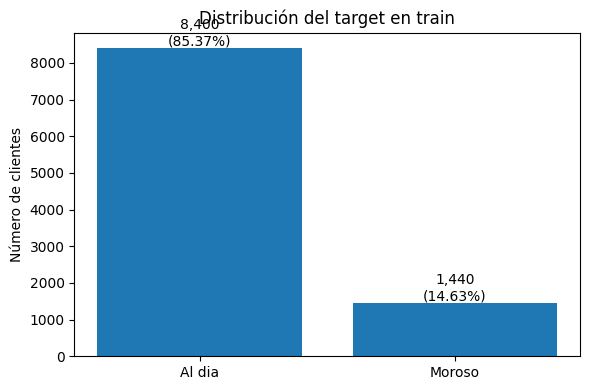

In [ ]:
eda_train = X_train.copy()
eda_train[TARGET] = y_train

target_counts = eda_train[TARGET].value_counts().sort_index()
target_pct = eda_train[TARGET].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Al dia', 'Moroso']
bars = ax.bar(labels, target_counts.values)
ax.set_title('Distribución del target en train')
ax.set_ylabel('Número de clientes')
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

## 3.2 Valores faltantes y `score_externo`

En M1, `score_externo` fue la principal variable con faltantes y el patrón era mucho más frecuente entre morosos. Se vuelve a cuantificar sobre la población binaria para verificar que la ausencia no sea ignorada durante el modelado.

,nulos,porcentaje
score_externo,854,8.68
edad,166,1.69
ingreso_mensual,0,0.00
anio_vinculacion,0,0.00
nivel_educativo,0,0.00
ciudad,0,0.00


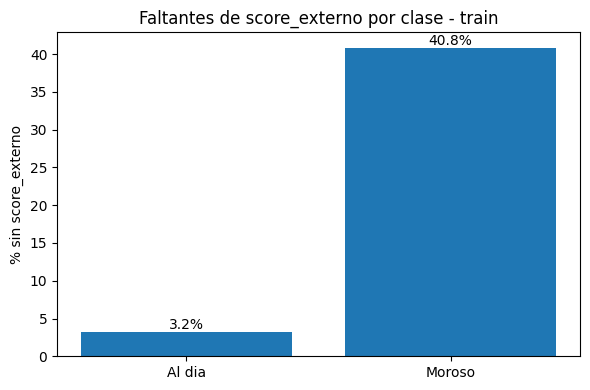

Interpretación: la ausencia de score_externo no es homogénea entre clases. Por eso no se rellena globalmente; la imputación se aprende dentro de cada fold.


In [ ]:
missing_summary = pd.DataFrame({
    'nulos': eda_train[FEATURES].isna().sum(),
    'porcentaje': (eda_train[FEATURES].isna().mean() * 100).round(2),
}).sort_values('porcentaje', ascending=False)
display(missing_summary)

score_missing_by_target = (
    eda_train
    .assign(score_faltante=eda_train['score_externo'].isna())
    .groupby(TARGET)['score_faltante']
    .mean()
    .mul(100)
    .rename(index={0: 'Al dia', 1: 'Moroso'})
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(score_missing_by_target.index, score_missing_by_target.values)
ax.set_title('Faltantes de score_externo por clase - train')
ax.set_ylabel('% sin score_externo')
for bar, value in zip(bars, score_missing_by_target.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.1f}%',
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

print(
    'Interpretación: la ausencia de score_externo no es homogénea entre clases. '
    'Por eso no se rellena globalmente; la imputación se aprende dentro de cada fold.'
)

## 3.3 Variables numéricas frente a la mora

Se comparan únicamente los cuatro predictores numéricos seguros. Los boxplots permiten observar desplazamientos entre clases sin convertir esos patrones en reglas determinísticas.

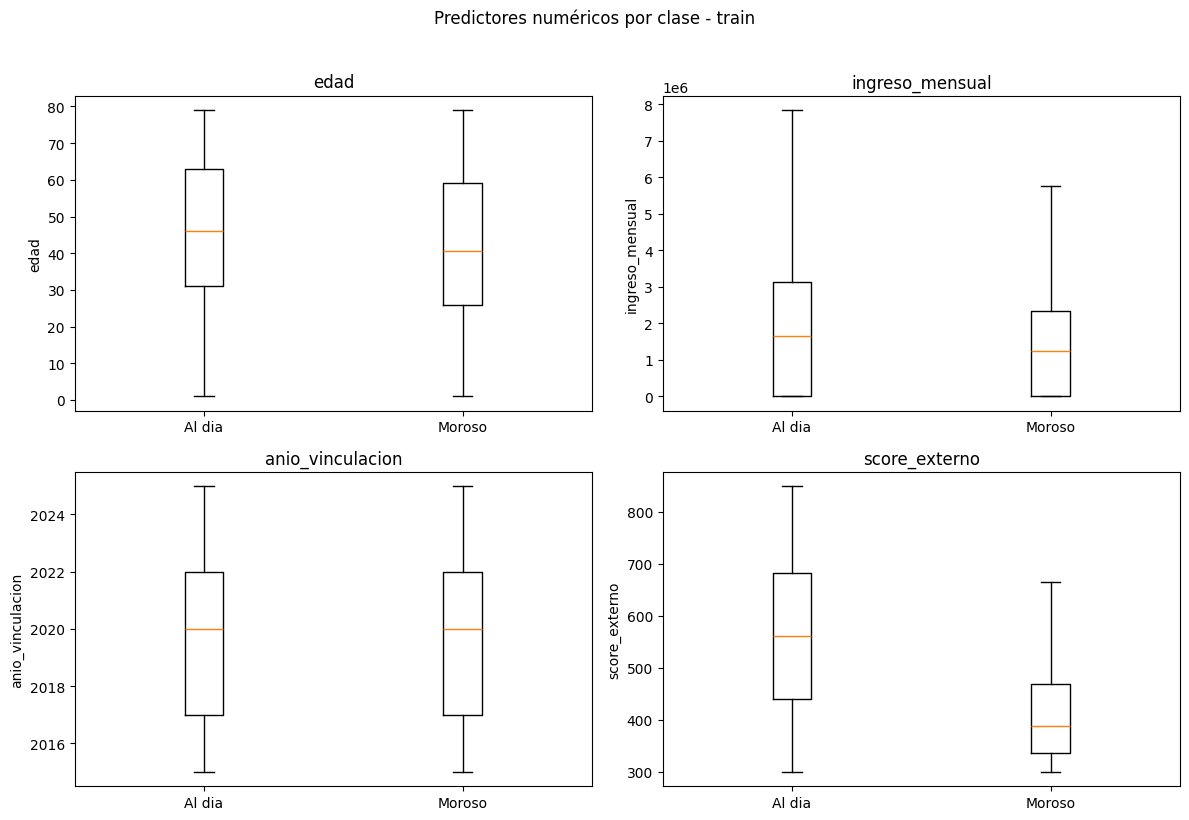

,edad,ingreso_mensual,anio_vinculacion,score_externo
target_moroso,,,,
Al dia,46.0,1659013.5,2020.0,561.0
Moroso,40.5,1229304.5,2020.0,389.0


In [ ]:
eda_numeric = eda_train[NUMERIC_FEATURES + [TARGET]].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.ravel(), NUMERIC_FEATURES):
    data_0 = eda_numeric.loc[eda_numeric[TARGET] == 0, feature].dropna()
    data_1 = eda_numeric.loc[eda_numeric[TARGET] == 1, feature].dropna()
    ax.boxplot([data_0, data_1], tick_labels=['Al dia', 'Moroso'], showfliers=False)
    ax.set_title(feature)
    ax.set_ylabel(feature)
plt.suptitle('Predictores numéricos por clase - train', y=1.02)
plt.tight_layout()
plt.show()

numeric_medians = (
    eda_numeric
    .groupby(TARGET)[NUMERIC_FEATURES]
    .median()
    .rename(index={0: 'Al dia', 1: 'Moroso'})
)
display(numeric_medians)

## 3.4 Variables categóricas

Para las variables categóricas se analiza la **tasa de mora por categoría**, no solo el volumen. Esto permite detectar grupos con diferente concentración de la clase positiva sin asumir causalidad.

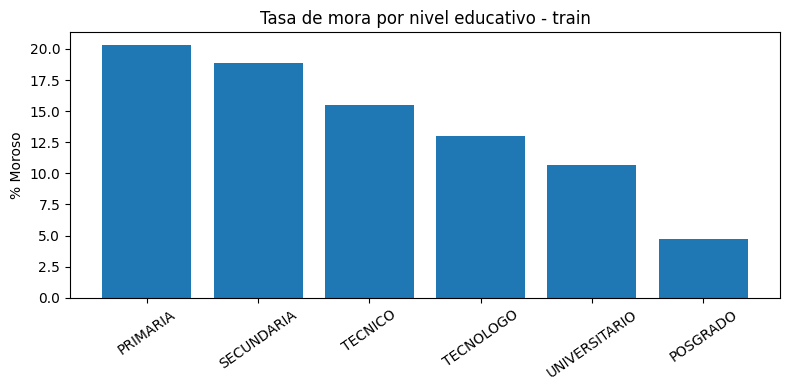

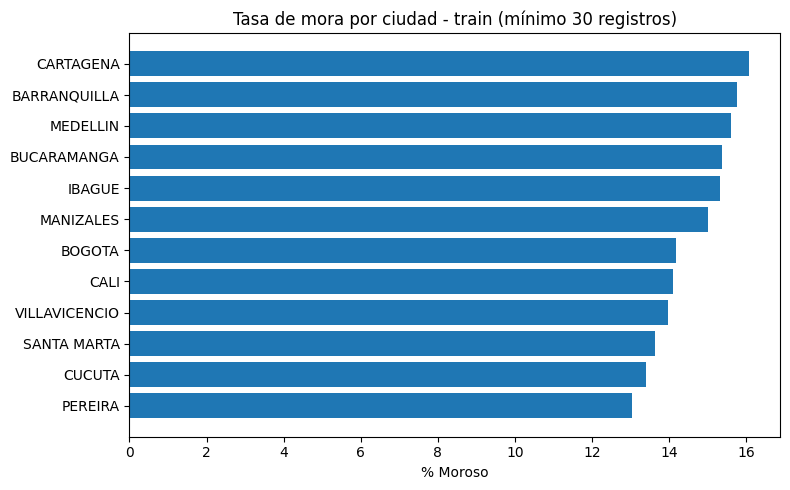

Nota: estas diferencias son descriptivas y no implican causalidad.


In [ ]:
def mora_rate_table(data, feature, min_count=1):
    table = (
        data.groupby(feature)[TARGET]
        .agg(cantidad='size', tasa_mora='mean')
        .reset_index()
    )
    table = table[table['cantidad'] >= min_count].copy()
    table['tasa_mora_pct'] = table['tasa_mora'] * 100
    return table.sort_values('tasa_mora_pct', ascending=False)


education_rate = mora_rate_table(eda_train, 'nivel_educativo')
city_rate = mora_rate_table(eda_train, 'ciudad', min_count=30)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(education_rate['nivel_educativo'], education_rate['tasa_mora_pct'])
ax.set_title('Tasa de mora por nivel educativo - train')
ax.set_ylabel('% Moroso')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

city_plot = city_rate.sort_values('tasa_mora_pct')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(city_plot['ciudad'], city_plot['tasa_mora_pct'])
ax.set_title('Tasa de mora por ciudad - train (mínimo 30 registros)')
ax.set_xlabel('% Moroso')
plt.tight_layout()
plt.show()

print('Nota: estas diferencias son descriptivas y no implican causalidad.')

## 3.5 Correlación entre predictores numéricos seguros

Se calcula Pearson únicamente sobre las variables numéricas que realmente entran al modelo. Esto evita mezclar el análisis con variables excluidas por riesgo temporal.

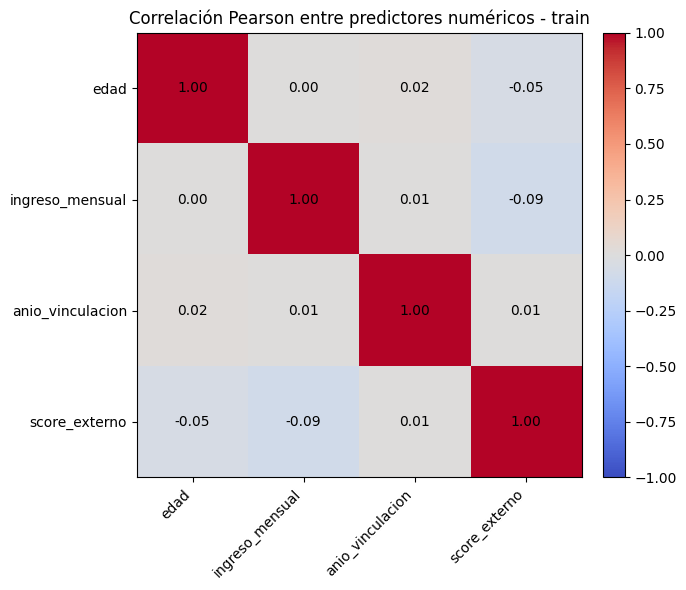

Mayor correlación absoluta entre predictores numéricos seguros: 0.093


In [ ]:
corr = X_train[NUMERIC_FEATURES].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(NUMERIC_FEATURES)), NUMERIC_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(NUMERIC_FEATURES)), NUMERIC_FEATURES)
for i in range(len(NUMERIC_FEATURES)):
    for j in range(len(NUMERIC_FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlación Pearson entre predictores numéricos - train')
plt.tight_layout()
plt.show()

upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).abs()
max_corr = upper_triangle.max().max()
print(f'Mayor correlación absoluta entre predictores numéricos seguros: {max_corr:.3f}')

### Hallazgos principales del EDA

La siguiente celda resume con cifras calculadas en **train** los patrones más relevantes para el modelado. Se reportan asociaciones descriptivas; no se interpretan como relaciones causales ni como reglas de decisión aisladas.

In [ ]:
score_medians = numeric_medians['score_externo']
income_medians = numeric_medians['ingreso_mensual']
age_medians = numeric_medians['edad']

print(f'1. Moroso representa {100 * y_train.mean():.2f}% del conjunto de train.')
print(
    f'2. Faltantes de score_externo: Al día {score_missing_by_target["Al dia"]:.1f}% '
    f'vs Moroso {score_missing_by_target["Moroso"]:.1f}%.'
)
print(
    f'3. Mediana score_externo: Al día {score_medians["Al dia"]:.0f} '
    f'vs Moroso {score_medians["Moroso"]:.0f}.'
)
print(
    f'4. Mediana ingreso_mensual: Al día ${income_medians["Al dia"]:,.0f} '
    f'vs Moroso ${income_medians["Moroso"]:,.0f}.'
)
print(
    f'5. Mediana edad: Al día {age_medians["Al dia"]:.0f} '
    f'vs Moroso {age_medians["Moroso"]:.0f}.'
)
print(f'6. Mayor correlación absoluta entre predictores numéricos seguros: {max_corr:.3f}.')
print(
    '7. El EDA no modifica la lista de features: las variables con temporalidad '
    'no demostrable continúan excluidas por riesgo de leakage.'
)


1. Moroso representa 14.63% del conjunto de train.
2. Faltantes de score_externo: Al día 3.2% vs Moroso 40.8%.
3. Mediana score_externo: Al día 561 vs Moroso 389.
4. Mediana ingreso_mensual: Al día $1,659,014 vs Moroso $1,229,304.
5. Mediana edad: Al día 46 vs Moroso 40.
6. Mayor correlación absoluta entre predictores numéricos seguros: 0.093.
7. El EDA no modifica la lista de features: las variables con temporalidad no demostrable continúan excluidas por riesgo de leakage.


# 4. Modelado

Se comparan dos modelos sobre **train** mediante validación cruzada estratificada de 5 folds:

- **Regresión Logística:** baseline interpretable y lineal.
- **HistGradientBoostingClassifier:** challenger capaz de capturar relaciones no lineales e interacciones.

El preprocesamiento queda encapsulado en `ColumnTransformer + Pipeline`, evitando que imputación, escalamiento o codificación aprendan información del test.

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        solver='liblinear',
    )),
])

challenger_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=RANDOM_SEED,
        early_stopping=False,
    )),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

baseline_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)
challenger_scores = cross_val_score(
    challenger_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)

comparison = pd.DataFrame({
    'modelo': ['Regresion Logistica', 'HistGradientBoosting'],
    'auc_cv_media': [baseline_scores.mean(), challenger_scores.mean()],
    'auc_cv_std': [baseline_scores.std(), challenger_scores.std()],
}).round(4)

display(comparison)

,modelo,auc_cv_media,auc_cv_std
0,Regresion Logistica,0.7353,0.0049
1,HistGradientBoosting,0.8593,0.0070


## 4.1 Optimización del challenger con Optuna

Se usa Optuna con `TPESampler`, semilla 42 y 50 trials. Cada trial se evalúa con AUC-ROC promedio en 5-fold CV usando únicamente `X_train` e `y_train`. El conjunto de test permanece aislado.

In [ ]:
SEARCH_SPACE = {
    'learning_rate': '0.02 a 0.20 (log)',
    'max_iter': '100 a 350',
    'max_leaf_nodes': '15 a 63',
    'min_samples_leaf': '10 a 60',
    'l2_regularization': '1e-5 a 10 (log)',
}

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)


def objective(trial):
    params = {
        'classifier__learning_rate': trial.suggest_float(
            'learning_rate', 0.02, 0.20, log=True
        ),
        'classifier__max_iter': trial.suggest_int(
            'max_iter', 100, 350, step=50
        ),
        'classifier__max_leaf_nodes': trial.suggest_int(
            'max_leaf_nodes', 15, 63
        ),
        'classifier__min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 10, 60
        ),
        'classifier__l2_regularization': trial.suggest_float(
            'l2_regularization', 1e-5, 10.0, log=True
        ),
    }
    candidate = clone(challenger_pipeline).set_params(**params)
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
    )
    return float(scores.mean())


study.optimize(
    objective,
    n_trials=50,
    n_jobs=1,
    show_progress_bar=False,
)

best_pipeline = clone(challenger_pipeline).set_params(
    **{f'classifier__{key}': value for key, value in study.best_params.items()}
)
best_pipeline.fit(X_train, y_train)

print(f'Mejor AUC CV: {study.best_value:.4f}')
print('Mejores hiperparámetros:')
for key, value in study.best_params.items():
    print(f'  - {key}: {value}')

Mejor AUC CV: 0.8692
Mejores hiperparámetros:
  - learning_rate: 0.021129187785442333
  - max_iter: 150
  - max_leaf_nodes: 15
  - min_samples_leaf: 26
  - l2_regularization: 5.4753321290292246e-05


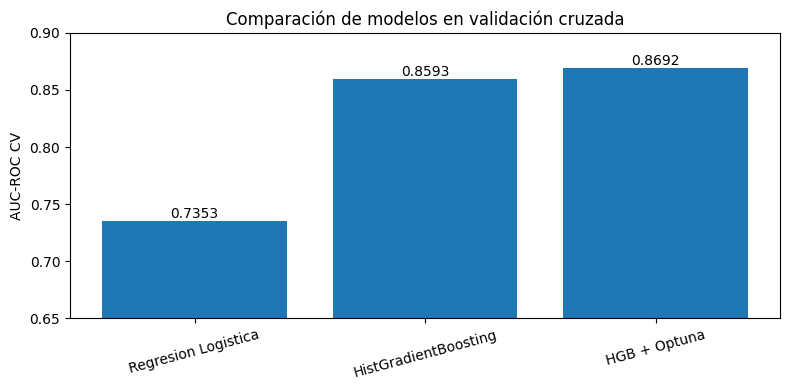

Mejora del challenger frente al baseline: 0.1240 AUC.
Mejora adicional de Optuna: 0.0100 AUC.


In [ ]:
model_comparison = pd.DataFrame({
    'modelo': [
        'Regresion Logistica',
        'HistGradientBoosting',
        'HGB + Optuna',
    ],
    'auc_cv': [
        baseline_scores.mean(),
        challenger_scores.mean(),
        study.best_value,
    ],
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_comparison['modelo'], model_comparison['auc_cv'])
ax.set_ylim(0.65, 0.90)
ax.set_ylabel('AUC-ROC CV')
ax.set_title('Comparación de modelos en validación cruzada')
ax.tick_params(axis='x', rotation=15)
for bar, value in zip(bars, model_comparison['auc_cv']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.4f}',
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

print(
    f'Mejora del challenger frente al baseline: '
    f'{challenger_scores.mean() - baseline_scores.mean():.4f} AUC.'
)
print(
    f'Mejora adicional de Optuna: '
    f'{study.best_value - challenger_scores.mean():.4f} AUC.'
)

## 4.2 Selección del threshold operativo

El threshold **no se ajusta sobre test**. Se generan predicciones *out-of-fold* en train y se buscan thresholds entre 0,05 y 0,95. Se exige `precision >= 0.40` y `recall >= 0.70`; entre las alternativas válidas se selecciona la de mayor F1.

In [ ]:
y_proba_oof = cross_val_predict(
    clone(best_pipeline),
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

rows = []
for threshold in np.arange(0.05, 0.951, 0.01):
    y_pred_oof = (y_proba_oof >= threshold).astype(int)
    rows.append({
        'threshold': float(threshold),
        'precision': precision_score(y_train, y_pred_oof, zero_division=0),
        'recall': recall_score(y_train, y_pred_oof, zero_division=0),
        'f1': f1_score(y_train, y_pred_oof, zero_division=0),
    })

threshold_results = pd.DataFrame(rows)
valid_thresholds = threshold_results[
    (threshold_results['precision'] >= 0.40) &
    (threshold_results['recall'] >= 0.70)
].copy()

if not valid_thresholds.empty:
    best_threshold_row = valid_thresholds.sort_values(
        ['f1', 'recall'], ascending=False
    ).iloc[0]
    threshold_status = 'Cumple precision >= 0.40 y recall >= 0.70 en OOF.'
else:
    best_threshold_row = threshold_results.sort_values(
        ['f1', 'recall'], ascending=False
    ).iloc[0]
    threshold_status = 'No hubo threshold que cumpliera ambas metas; se seleccionó por F1.'

optimal_threshold = float(best_threshold_row['threshold'])

print(threshold_status)
print(f'Threshold: {optimal_threshold:.2f}')
print(f'Precision OOF: {best_threshold_row["precision"]:.4f}')
print(f'Recall OOF   : {best_threshold_row["recall"]:.4f}')
print(f'F1 OOF       : {best_threshold_row["f1"]:.4f}')

Cumple precision >= 0.40 y recall >= 0.70 en OOF.
Threshold: 0.59
Precision OOF: 0.4487
Recall OOF   : 0.7111
F1 OOF       : 0.5502


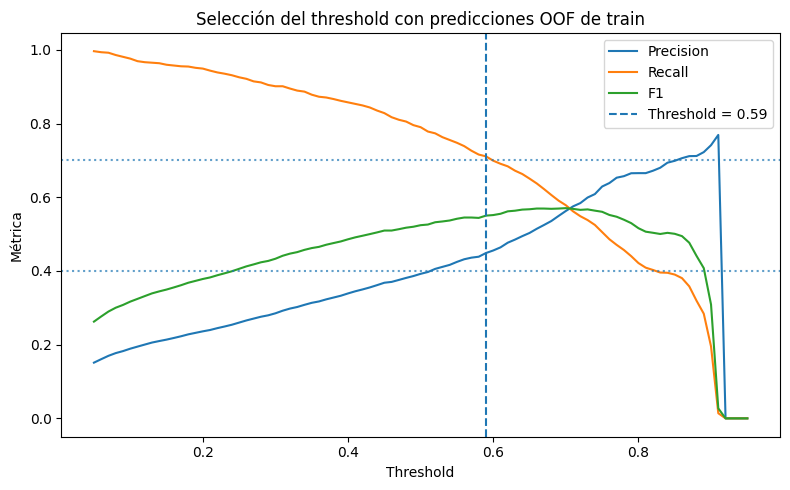

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_results['threshold'], threshold_results['precision'], label='Precision')
ax.plot(threshold_results['threshold'], threshold_results['recall'], label='Recall')
ax.plot(threshold_results['threshold'], threshold_results['f1'], label='F1')
ax.axvline(optimal_threshold, linestyle='--', label=f'Threshold = {optimal_threshold:.2f}')
ax.axhline(0.40, linestyle=':', alpha=0.7)
ax.axhline(0.70, linestyle=':', alpha=0.7)
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title('Selección del threshold con predicciones OOF de train')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Evaluación final del modelo

El modelo y el threshold quedan congelados antes de tocar test. La evaluación final reporta las métricas definidas en M2 y complementa el resultado con curvas y análisis explícito de falsos positivos y falsos negativos.

In [ ]:
best_pipeline.fit(X_train, y_train)
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

auc_test = roc_auc_score(y_test, y_proba_test)
precision_test = precision_score(y_test, y_pred_test, zero_division=0)
recall_test = recall_score(y_test, y_pred_test, zero_division=0)
f1_test = f1_score(y_test, y_pred_test, zero_division=0)

metrics_table = pd.DataFrame({
    'metrica': ['AUC-ROC', 'Precision Moroso', 'Recall Moroso', 'F1 Moroso'],
    'resultado': [auc_test, precision_test, recall_test, f1_test],
})
display(metrics_table.style.format({'resultado': '{:.4f}'}))

print('\nClassification report:')
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Al dia', 'Moroso'],
    digits=4,
    zero_division=0,
))

,metrica,resultado
0,AUC-ROC,0.8681
1,Precision Moroso,0.4470
2,Recall Moroso,0.7028
3,F1 Moroso,0.5464



Classification report:
              precision    recall  f1-score   support

      Al dia     0.9435    0.8510    0.8948      2100
      Moroso     0.4470    0.7028    0.5464       360

    accuracy                         0.8293      2460
   macro avg     0.6953    0.7769    0.7206      2460
weighted avg     0.8708    0.8293    0.8439      2460



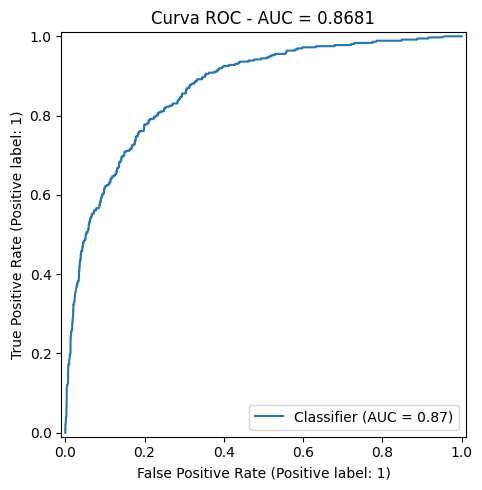

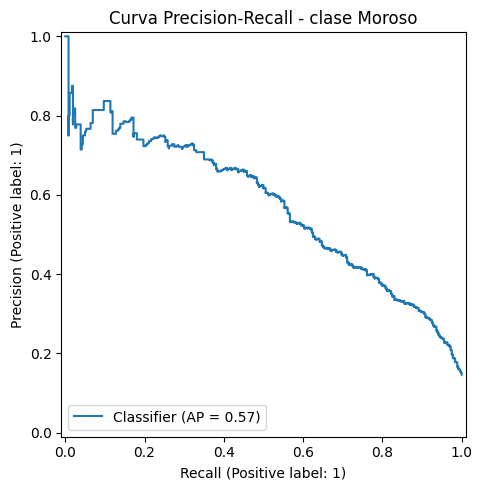

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=ax)
ax.set_title(f'Curva ROC - AUC = {auc_test:.4f}')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, ax=ax)
ax.set_title('Curva Precision-Recall - clase Moroso')
plt.tight_layout()
plt.show()

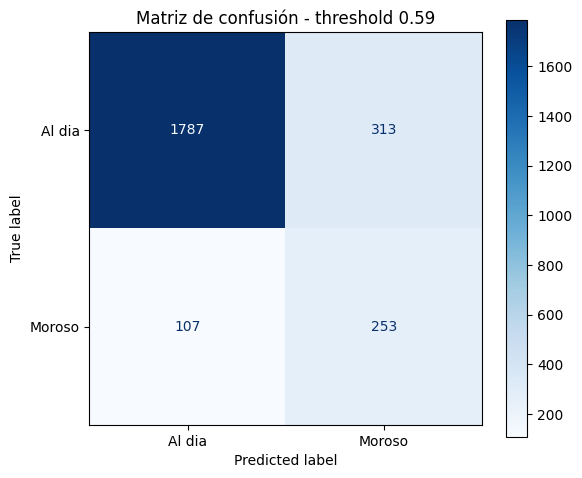

Verdaderos negativos: 1787
Falsos positivos:      313
Falsos negativos:      107
Verdaderos positivos:  253


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=['Al dia', 'Moroso'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Matriz de confusión - threshold {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f'Verdaderos negativos: {tn}')
print(f'Falsos positivos:      {fp}')
print(f'Falsos negativos:      {fn}')
print(f'Verdaderos positivos:  {tp}')

## 5.1 Interpretación de errores

- **Falso negativo (Moroso clasificado como Al día):** es el error más sensible para FrescaMar porque puede dejar sin alerta a un cliente que posteriormente presenta mora.
- **Falso positivo (Al día clasificado como Moroso):** genera revisión o restricción innecesaria sobre un cliente cumplido.

El threshold busca un compromiso entre ambos errores. Por eso se definió previamente con validación OOF y no se retoca después de observar test.

In [ ]:
print(
    f'El modelo detecta {tp} de {tp + fn} morosos del test '
    f'({recall_test:.2%} de recall).'
)
print(
    f'De {tp + fp} alertas emitidas, {tp} corresponden a morosos reales '
    f'({precision_test:.2%} de precision).'
)
print(
    f'Quedan {fn} morosos sin detectar y se generan {fp} falsas alertas.'
)

El modelo detecta 253 de 360 morosos del test (70.28% de recall).
De 566 alertas emitidas, 253 corresponden a morosos reales (44.70% de precision).
Quedan 107 morosos sin detectar y se generan 313 falsas alertas.


## 5.2 Verificación de generalización

Se compara AUC de train y test. Si la diferencia supera 0,10, el notebook **se detiene** para revisar leakage o sobreajuste. No se modifica el modelo después de mirar test.

In [ ]:
train_proba = best_pipeline.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, train_proba)
auc_gap = abs(auc_train - auc_test)

print(f'AUC Train: {auc_train:.4f}')
print(f'AUC Test : {auc_test:.4f}')
print(f'Gap      : {auc_gap:.4f}')

if auc_gap > 0.10:
    raise RuntimeError(
        'ALERTA: abs(AUC_train - AUC_test) > 0.10. '
        'Revisar leakage/sobreajuste sin reajustar sobre test.'
    )

leakage_status = 'Diferencia aceptable - pipeline validado'
print(leakage_status)

AUC Train: 0.8935
AUC Test : 0.8681
Gap      : 0.0254
Diferencia aceptable - pipeline validado


# 6. Serialización y artefactos del prototipo

El pipeline completo se serializa con `joblib`, se vuelve a cargar y se verifica que reproduzca las probabilidades de una muestra. También se exportan las métricas principales para trazabilidad.

In [ ]:
pipeline_path = MODEL_DIR / 'solaris_pipeline_v1.pkl'
joblib.dump(best_pipeline, pipeline_path)
loaded_pipeline = joblib.load(pipeline_path)

original_sample = best_pipeline.predict_proba(X_test.head(10))[:, 1]
loaded_sample = loaded_pipeline.predict_proba(X_test.head(10))[:, 1]
pkl_load_ok = bool(np.allclose(original_sample, loaded_sample))
if not pkl_load_ok:
    raise RuntimeError('El PKL no reproduce las predicciones del pipeline original.')

metrics = {
    'fecha_ejecucion': datetime.now().isoformat(timespec='seconds'),
    'random_seed': RANDOM_SEED,
    'entorno': {
        'python': sys.version.split()[0],
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'matplotlib': matplotlib.__version__,
        'joblib': joblib.__version__,
        'optuna': optuna.__version__,
    },
    'n_filas_modelado': int(len(df_model)),
    'n_ciudades_normalizadas': int(df_model['ciudad'].nunique(dropna=True)),
    'features': FEATURES,
    'modelo_final': 'HistGradientBoostingClassifier',
    'metodo_optimizacion': 'Optuna - TPESampler',
    'n_trials': int(len(study.trials)),
    'best_cv_auc': float(study.best_value),
    'mejores_hiperparametros': study.best_params,
    'threshold_operativo': float(optimal_threshold),
    'auc_train': float(auc_train),
    'auc_test': float(auc_test),
    'diferencia_auc_train_test': float(auc_gap),
    'precision_test': float(precision_test),
    'recall_test': float(recall_test),
    'f1_test': float(f1_test),
    'estado_leakage': leakage_status,
    'pkl_cargable': pkl_load_ok,
}

metrics_path = OUTPUT_DIR / 'metricas_m3.json'
with open(metrics_path, 'w', encoding='utf-8') as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)

print('Pipeline:', pipeline_path)
print('Métricas:', metrics_path)
print('PKL cargable:', pkl_load_ok)

Pipeline: models/solaris_pipeline_v1.pkl
Métricas: outputs/metricas_m3.json
PKL cargable: True


# 7. Conclusiones

La conclusión se genera a partir de los resultados de **esta ejecución** para evitar inconsistencias con métricas de módulos anteriores.

In [ ]:
print('Modelo final: HistGradientBoostingClassifier optimizado con Optuna')
print(f'AUC CV optimizado : {study.best_value:.4f}')
print(f'AUC Test          : {auc_test:.4f}')
print(f'Precision Moroso  : {precision_test:.4f}')
print(f'Recall Moroso     : {recall_test:.4f}')
print(f'F1 Moroso         : {f1_test:.4f}')
print(f'Threshold         : {optimal_threshold:.2f}')
print(f'Gap Train-Test    : {auc_gap:.4f}')
print()
print(
    f'El modelo supera la línea base logística en '
    f'{study.best_value - baseline_scores.mean():.4f} puntos de AUC CV.'
)
print(
    f'En test detecta {tp} de {tp + fn} morosos y produce {fp} falsas alertas. '
    'El threshold se seleccionó exclusivamente con predicciones OOF de train.'
)


Modelo final: HistGradientBoostingClassifier optimizado con Optuna
AUC CV optimizado : 0.8692
AUC Test          : 0.8681
Precision Moroso  : 0.4470
Recall Moroso     : 0.7028
F1 Moroso         : 0.5464
Threshold         : 0.59
Gap Train-Test    : 0.0254

El modelo supera la línea base logística en 0.1340 puntos de AUC CV.
En test detecta 253 de 360 morosos y produce 313 falsas alertas. El threshold se seleccionó exclusivamente con predicciones OOF de train.


### Limitaciones y siguientes pasos

1. El archivo actual es un *snapshot*; falta `fecha_corte`/`fecha_evento` para una validación temporal real.
2. `score_externo` presenta un patrón de faltantes asociado a la clase y debe seguir monitoreándose.
3. La normalización de `ciudad` se valida explícitamente; cualquier categoría no resuelta debe revisarse antes de considerar cerrada la limpieza.
4. El modelo es un prototipo de **soporte a la decisión**, no un sistema de aprobación/negación automática.
5. Antes de producción se requiere validación *out-of-time*, análisis de calibración, monitoreo de *drift* y validación de impacto con FrescaMar.